Project Title :
Crop Yield Prediction

Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns



Load Dataset

In [40]:
df = pd.read_csv("../data/Crop Yeild Data.csv")

1. Data Exploration:
● Explore the data, list down the unique values in each feature and find its length.

In [41]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  str    
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  str    
 3   State            19689 non-null  str    
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), str(3)
memory usage: 2.0 MB


In [43]:
print("DataFrame Shape:", df.shape)

DataFrame Shape: (19689, 13)


In [44]:
for col in df.columns:
  unique_value = df[col].unique()
  unique_count = df[col].nunique()
  print(f"Column: {col}")
  print(f"Unique values ({unique_count}): {unique_value}\n")

Column: Crop
Unique values (55): <StringArray>
[             'Arecanut',             'Arhar/Tur',           'Castor seed',
              'Coconut ',          'Cotton(lint)',          'Dry chillies',
                  'Gram',                  'Jute',               'Linseed',
                 'Maize',                 'Mesta',            'Niger seed',
                 'Onion',    'Other  Rabi pulses',                'Potato',
     'Rapeseed &Mustard',                  'Rice',               'Sesamum',
         'Small millets',             'Sugarcane',          'Sweet potato',
               'Tapioca',               'Tobacco',              'Turmeric',
                 'Wheat',                 'Bajra',          'Black pepper',
              'Cardamom',             'Coriander',                'Garlic',
                'Ginger',             'Groundnut',            'Horse-gram',
                 'Jowar',                  'Ragi',             'Cashewnut',
                'Banana',              'S

● Perform the statistical analysis and renaming of the columns.

In [45]:
print(df.describe())

          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04     19689.000000   
mean    2009.127584  1.799266e+05  1.643594e+07      1437.755186   
std        6.498099  7.328287e+05  2.630568e+08       816.909592   
min     1997.000000  5.000000e-01  0.000000e+00       301.300000   
25%     2004.000000  1.390000e+03  1.393000e+03       940.700000   
50%     2010.000000  9.317000e+03  1.380400e+04      1247.600000   
75%     2015.000000  7.511200e+04  1.227180e+05      1643.700000   
max     2020.000000  5.080810e+07  6.326000e+09      6552.700000   

         Fertilizer     Pesticide         Yield  Avg_Temperature  \
count  1.968900e+04  1.968900e+04  19689.000000     19689.000000   
mean   2.410331e+07  4.884835e+04     79.954011        23.831279   
std    9.494600e+07  2.132874e+05    878.306194         5.847672   
min    5.417000e+01  9.000000e-02      0.000000        -5.115000   
25%    1.880146e+05  3.567000e+02      0.600000

In [46]:
print(df.describe(include = 'object'))

         Crop       Season      State
count   19689        19689      19689
unique     55            6         30
top      Rice  Kharif       Karnataka
freq     1197         8232       1432


C:\Users\Ranjana\AppData\Local\Temp\ipykernel_26036\2613557822.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include = 'object'))


2. Data Cleaning:
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

check missing values

In [14]:
print(df.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64


There is no missing values

In [15]:
#Remove all duplicate rows
df.duplicated().sum()

np.int64(0)

Check Data Types

In [16]:
df.dtypes

Crop                   str
Crop_Year            int64
Season                 str
State                  str
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
Avg_Temperature    float64
Max_Temperature    float64
Min_Temperature    float64
dtype: object

In [17]:
df["Crop"] = df["Crop"].astype("category")
df["State"] = df["State"].astype("category")
df["Season"] = df["Season"].astype("category")

Check Skewness

In [50]:

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].skew().sort_values(ascending=False)
skewness = df[numeric_cols].skew()

print(skewness)

Crop_Year          -0.162656
Area               21.858218
Production         19.299193
Annual_Rainfall     2.131785
Fertilizer         13.412599
Pesticide          25.635746
Yield              12.785265
Avg_Temperature    -3.355612
Max_Temperature    -2.706472
Min_Temperature    -3.268365
dtype: float64


Apply log transformation only to highly skewed columns

In [51]:
skewed_cols = ['Area', 'Production', 'Fertilizer', 'Pesticide']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

Visualise Outliers

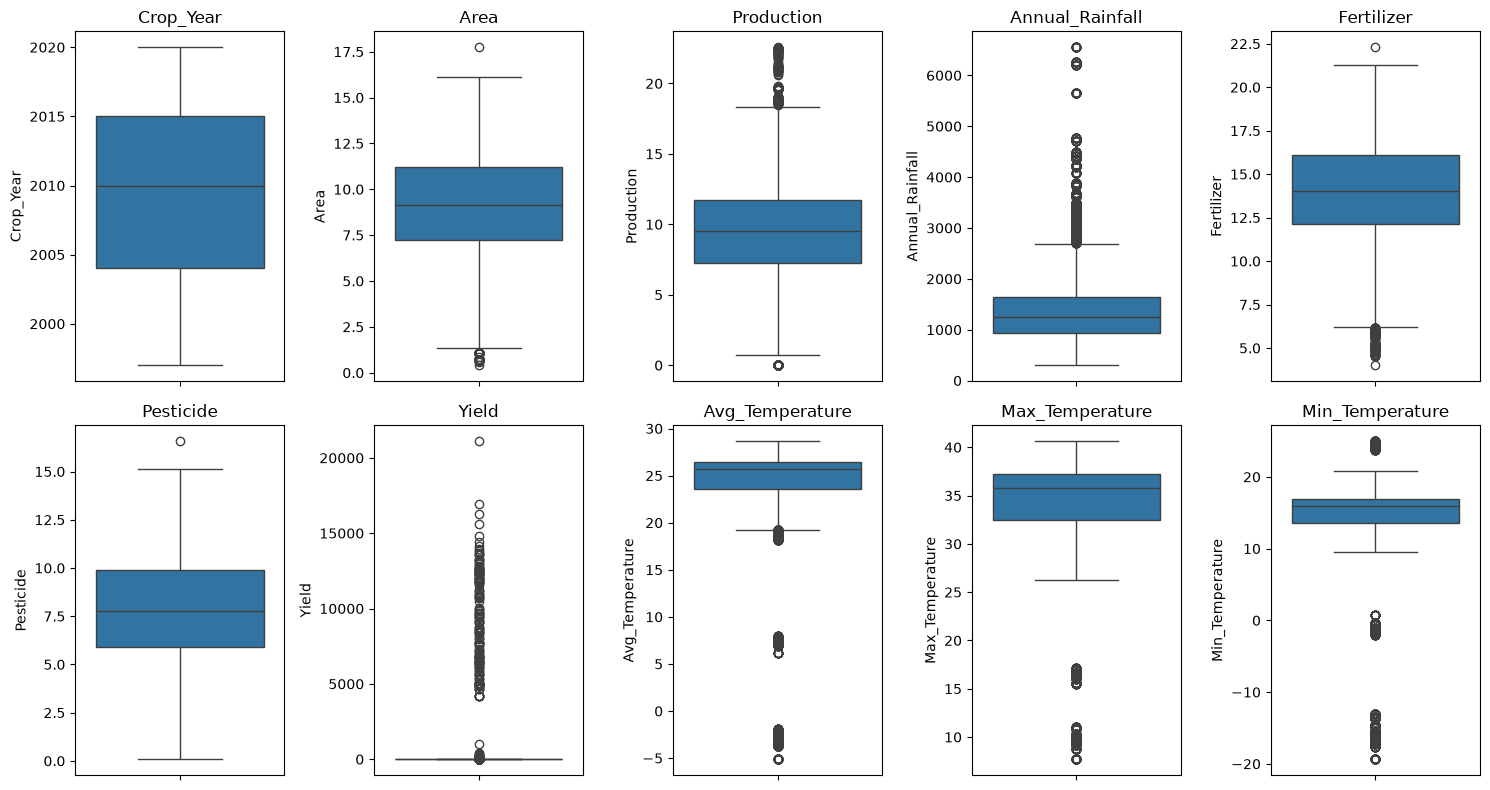

In [53]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Finding Outliers

In [54]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)

    return df

Handle Skewness

In [55]:
for col in ['Area',
            'Production',
            'Fertilizer',
            'Pesticide',
            'Yield']:
    df = cap_outliers(df, col)

Verify the shape

In [56]:
print("DataFrame Shape:", df.shape)

DataFrame Shape: (19689, 13)


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  str    
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  str    
 3   State            19689 non-null  str    
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  float64
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(9), int64(1), str(3)
memory usage: 2.0 MB


In [59]:
from pathlib import Path

# Current notebook location
print(Path.cwd())

# If notebook is in notebooks/
project_root = Path.cwd().parent

data_folder = project_root / "data"
data_folder.mkdir(exist_ok=True)  # Creates the folder if it doesn't exist

df.to_csv(data_folder / "crop_yield_preprocessed.csv", index=False)

c:\Users\Ranjana\Crop_Yield_Prediction\notebooks
